## Analysis of Causal Results

In [1]:
def default_params(): 
    return {
        'input_path' : '/workspaces/CodeSmells/data/extension/causality/results',
        'output_plots' : '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots',
        'treatment' : 'T4',
    }
params = default_params()

### Imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

### Dataset loading

In [4]:
# #code_smell_actual_prob_median, #code_smell_max_prob_median, #code_smell_min_prob_median, 
# #code_smell_actual_prob_mean, #code_smell_max_prob_mean, #code_smell_min_prob_mean, 
# #code_smell_psc_entropy, #code_smell_psc_relative,

####### results per smell, binary treatment 
causal_results_per_smell_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_psc_relative.json"),
}
####### results all smells, binary treatment 
causal_results_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_psc_relative_ALL.json"),
}
####### results per smell, categorical treatment 
causal_results_per_smell_categorical_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_psc_relative.json"),
}
####### results all smell, categorical treatment 
causal_results_categorical_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_psc_relative_ALL.json"),
}

In [5]:
causal_results_per_smell_dict['code_smell_psc_relative'].sort_values(by=['estimated_effect'], ascending=False)

,method_name,pearson_corr,spearman_corr,kendall_corr,estimated_effect,refutation_placebo_permute,refutation_unobserved_confounder,refutation_subset,intervention,s_msg_id
120,backdoor.propensity_score_matching,-0.003768,0.015974,0.013070,0.169110,"{'result': {'p_value': 0.9400000000000001, 'is...","{'result': None, 'new_effect': [0.097676770300...","{'result': {'p_value': 0.72, 'is_statistically...",P4,W0622
117,backdoor.propensity_score_matching,0.001686,0.029374,0.024031,0.124772,"{'result': {'p_value': 0.96, 'is_statistically...","{'result': None, 'new_effect': [0.049800618500...","{'result': {'p_value': 0.38, 'is_statistically...",P3,W0622
123,backdoor.propensity_score_matching,-0.001950,0.042299,0.034608,0.098115,"{'result': {'p_value': 0.92, 'is_statistically...","{'result': None, 'new_effect': [0.0558428648, ...","{'result': {'p_value': 0.54, 'is_statistically...",P2,W0622
327,backdoor.propensity_score_matching,0.186019,0.233179,0.190725,0.071380,"{'result': {'p_value': 0.92, 'is_statistically...","{'result': None, 'new_effect': [0.0184563633, ...","{'result': {'p_value': 0.88, 'is_statistically...",P4,W0102
144,backdoor.propensity_score_matching,-0.012709,-0.013475,-0.011091,0.064411,"{'result': {'p_value': 0.96, 'is_statistically...","{'result': None, 'new_effect': [0.0404971048, ...","{'result': {'p_value': 0.6000000000000001, 'is...",P3,C0321
...,...,...,...,...,...,...,...,...,...,...
68,backdoor.generalized_linear_model,-0.122382,-0.109044,-0.089133,-0.089952,"{'result': {'p_value': 0.86, 'is_statistically...","{'result': None, 'new_effect': [-0.09432359600...","{'result': {'p_value': 0.98, 'is_statistically...",P4,W0613
66,backdoor.propensity_score_matching,-0.122382,-0.109044,-0.089133,-0.115619,"{'result': {'p_value': 1.0, 'is_statistically_...","{'result': None, 'new_effect': [-0.1560760071,...","{'result': {'p_value': 0.98, 'is_statistically...",P4,W0613
81,backdoor.propensity_score_matching,-0.096042,-0.096532,-0.079491,-0.242050,"{'result': {'p_value': 0.96, 'is_statistically...","{'result': None, 'new_effect': [-0.2527901926,...","{'result': {'p_value': 0.04, 'is_statistically...",P3,C0304
84,backdoor.propensity_score_matching,-0.113991,-0.107512,-0.088572,-0.266606,"{'result': {'p_value': 1.0, 'is_statistically_...","{'result': None, 'new_effect': [-0.2785838881,...","{'result': {'p_value': 0.32, 'is_statistically...",P4,C0304


In [6]:
causal_results_per_smell_dict['code_smell_psc_relative'].groupby(['intervention', 's_msg_id']).describe()

pearson_corr                                    \
                             count      mean           std       min   
intervention s_msg_id                                                  
P2           C0103             3.0 -0.010181  0.000000e+00 -0.010181   
             C0114             3.0 -0.058608  8.498375e-18 -0.058608   
             C0116             3.0 -0.028988  0.000000e+00 -0.028988   
             C0123             3.0 -0.026663  4.249187e-18 -0.026663   
             C0200             3.0 -0.008386  0.000000e+00 -0.008386   
...                            ...       ...           ...       ...   
P4           W0718             3.0 -0.012875  0.000000e+00 -0.012875   
             W0719             3.0 -0.022647  0.000000e+00 -0.022647   
             W1309             3.0 -0.009913  0.000000e+00 -0.009913   
             W1406             3.0 -0.012017  2.124594e-18 -0.012017   
             W1514             3.0 -0.023661  0.000000e+00 -0.023661   

                                                              spearman_corr  \
                            25%       50%       75%       max         count   
intervention s_msg_id                                                         
P2           C0103    -0.010181 -0.010181 -0.010181 -0.010181           3.0   
             C0114    -0.058608 -0.058608 -0.058608 -0.058608           3.0   
             C0116    -0.028988 -0.028988 -0.028988 -0.028988           3.0   
             C0123    -0.026663 -0.026663 -0.026663 -0.026663           3.0   
             C0200    -0.008386 -0.008386 -0.008386 -0.008386           3.0   
...                         ...       ...       ...       ...           ...   
P4           W0718    -0.012875 -0.012875 -0.012875 -0.012875           3.0   
             W0719    -0.022647 -0.022647 -0.022647 -0.022647           3.0   
             W1309    -0.009913 -0.009913 -0.009913 -0.009913           3.0   
             W1406    -0.012017 -0.012017 -0.012017 -0.012017           3.0   
             W1514    -0.023661 -0.023661 -0.023661 -0.023661           3.0   

                                 ... kendall_corr           estimated_effect  \
                           mean  ...          75%       max            count   
intervention s_msg_id            ...                                           
P2           C0103    -0.015860  ...    -0.013004 -0.013004              3.0   
             C0114    -0.059091  ...    -0.048272 -0.048272              3.0   
             C0116    -0.024720  ...    -0.020194 -0.020194              3.0   
             C0123    -0.024207  ...    -0.019858 -0.019858              3.0   
             C0200    -0.004690  ...    -0.003832 -0.003832              3.0   
...                         ...  ...          ...       ...              ...   
P4           W0718    -0.024886  ...    -0.020661 -0.020661              3.0   
             W0719    -0.021658  ...    -0.017704 -0.017704              3.0   
             W1309    -0.006533  ...    -0.005367 -0.005367              3.0   
             W1406    -0.009414  ...    -0.007718 -0.007718              3.0   
             W1514    -0.019372  ...    -0.015938 -0.015938              3.0   

                                                                         \
                           mean       std       min       25%       50%   
intervention s_msg_id                                                     
P2           C0103    -0.005896  0.002740 -0.007478 -0.007478 -0.007478   
             C0114    -0.009482  0.007806 -0.013988 -0.013988 -0.013988   
             C0116     0.007321  0.029871 -0.009925 -0.009925 -0.009925   
             C0123    -0.011155  0.003406 -0.015087 -0.012138 -0.009188   
             C0200    -0.001803  0.001314 -0.003320 -0.002182 -0.001044   
...                         ...       ...       ...       ...       ...   
P4           W0718    -0.003490  0.003825 -0.005698 -0.005698 -0.005698   
             W0719    -0.013362  0.

### Plots

In [7]:
def plot_correlations(causal_df, outcome, correlation, method_name, output_dir, intervention = None):
    # Transforming the DataFrame using melt
    causal_df = causal_df[
        (causal_df['method_name'] == method_name)].copy()
    if intervention:
        causal_df = causal_df[
            (causal_df['method_name'] == method_name) &(causal_df['intervention'] == intervention)
        ].copy()
    correlation_plot_df = causal_df.melt(id_vars=['s_msg_id'], value_vars=[correlation, 'estimated_effect'],  var_name='type', value_name='value')

    # Create the plot
    plt.figure(figsize=(40, 6))
    barplot = sns.barplot(
        palette='mako',
        data=correlation_plot_df,
        x="s_msg_id",
        y="value",
        hue="type",
        alpha=0.8,
        errorbar=None)

    # Improve x-axis readability
    plt.xlabel("Smell Id", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.title(f"{correlation} vs ATE. Outcome [{outcome}], Treatment [{intervention}]", fontsize=14)

    # Move the legend outside for clarity
    plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    output_dir = f"{output_dir}/{params['treatment']}/{method_name}"
    if intervention:
        output_dir = f"{output_dir}/{params['treatment']}/{intervention}/{method_name}"

    create_folder(output_dir)
    plt.savefig(f"{output_dir}/{outcome}_{correlation}.png", bbox_inches="tight", dpi=300)
    plt.close()



In [8]:
def plot_correlations_binary_treatment(causal_results_per_smell_dict, method_names):
    for outcome, causal_df in causal_results_per_smell_dict.items():
        for correlation in ['pearson_corr', 'spearman_corr', 'kendall_corr']:
            for method_name in method_names:
                for intervention in causal_df['intervention'].unique():
                    plot_correlations(causal_df, outcome, correlation, method_name, '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots/binary_treatment', intervention)

In [9]:
def plot_correlations_categorical_treatment(causal_results_per_smell_dict, method_names):
    for outcome, causal_df in causal_results_per_smell_dict.items():
        for correlation in ['pearson_corr', 'spearman_corr', 'kendall_corr']:
            for method_name in method_names:
                    plot_correlations(causal_df, outcome, correlation, method_name, '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots/categorical_treatment')

In [10]:
method_names = ['backdoor.generalized_linear_model', 'backdoor.propensity_score_matching', 'backdoor.propensity_score_stratification', 'backdoor.propensity_score_weighting']

In [11]:
if params['treatment'] in ['T1', 'T2', 'T3', 'T4']:
    plot_correlations_binary_treatment(causal_results_per_smell_dict, method_names)


/tmp/ipykernel_1035552/1812138605.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
/tmp/ipykernel_1035552/1812138605.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
/tmp/ipykernel_1035552/1812138605.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
/tmp/ipykernel_1035552/1812138605.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an

In [12]:
if params['treatment'] in ['T2', 'T3']:
    plot_correlations_categorical_treatment(causal_results_per_smell_categorical_dict, method_names)

### Summary

In [14]:
outcome = 'code_smell_psc_relative'
causal_results_per_smell_categorical_dict[outcome].head(2)

,method_name,pearson_corr,spearman_corr,kendall_corr,estimated_effect,refutation_placebo_permute,refutation_unobserved_confounder,refutation_subset,intervention,s_msg_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P1,W0311
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P1,W0311


In [15]:
outcome = 'code_smell_psc_relative'
summary_df = causal_results_per_smell_dict[outcome][causal_results_per_smell_dict[outcome]['method_name']=='backdoor.propensity_score_matching'].copy()
#summary_df = summary_df[['intervention','s_msg_id','pearson_corr','estimated_effect', 'refutation_placebo_permute']].sort_values(by='estimated_effect', ascending=False)
summary_df = summary_df[['intervention','s_msg_id','estimated_effect']].sort_values(by='estimated_effect', ascending=False)
#summary_df['pearson_corr'] = summary_df['pearson_corr'].round(4)
summary_df['estimated_effect'] = summary_df['estimated_effect'].round(4)
#summary_df['refutation_placebo_permute'] = summary_df['refutation_placebo_permute'].map(lambda result: result['new_effect'])
#summary_df['refutation_placebo_permute'] = summary_df['refutation_placebo_permute'].round(4)


summary_df.groupby(['s_msg_id', 'intervention']).describe()


estimated_effect                                      \
                                 count    mean std     min     25%     50%   
s_msg_id intervention                                                        
C0103    P2                        1.0 -0.0027 NaN -0.0027 -0.0027 -0.0027   
         P3                        1.0  0.0218 NaN  0.0218  0.0218  0.0218   
         P4                        1.0  0.0051 NaN  0.0051  0.0051  0.0051   
C0114    P2                        1.0 -0.0005 NaN -0.0005 -0.0005 -0.0005   
         P3                        1.0  0.0202 NaN  0.0202  0.0202  0.0202   
...                                ...     ...  ..     ...     ...     ...   
W1406    P3                        1.0 -0.0127 NaN -0.0127 -0.0127 -0.0127   
         P4                        1.0 -0.0078 NaN -0.0078 -0.0078 -0.0078   
W1514    P2                        1.0 -0.0030 NaN -0.0030 -0.0030 -0.0030   
         P3                        1.0 -0.0035 NaN -0.0035 -0.0035 -0.0035   
         P4                        1.0 -0.0042 NaN -0.0042 -0.0042 -0.0042   

                                       
                          75%     max  
s_msg_id intervention                  
C0103    P2           -0.0027 -0.0027  
         P3            0.0218  0.0218  
         P4            0.0051  0.0051  
C0114    P2           -0.0005 -0.0005  
         P3            0.0202  0.0202  
...                       ...     ...  
W1406    P3           -0.0127 -0.0127  
         P4           -0.0078 -0.0078  
W1514    P2           -0.0030 -0.0030  
         P3           -0.0035 -0.0035  
         P4           -0.0042 -0.0042  

[123 rows x 8 columns]

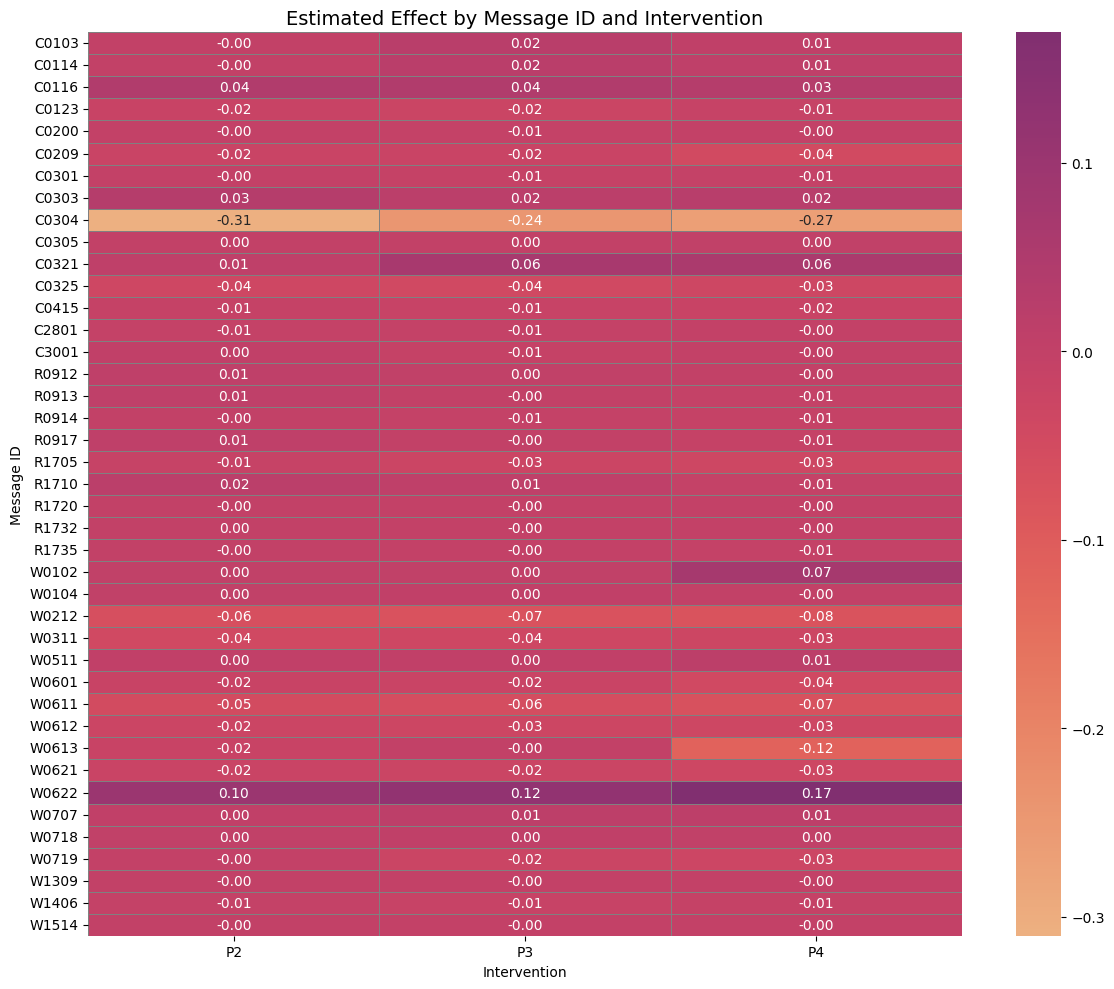

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume df is the original dataframe
pivot_df = summary_df.pivot(index='s_msg_id', columns='intervention', values='estimated_effect')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="flare", center=0, linewidths=0.5, linecolor='gray')
plt.title("Estimated Effect by Message ID and Intervention", fontsize=14)
plt.xlabel("Intervention")
plt.ylabel("Message ID")
plt.tight_layout()
plt.show()

